# 01 - Análisis Exploratorio de Datos

Este notebook realiza el análisis exploratorio completo del dataset de cáncer de piel en Chile, incluyendo visualizaciones y detección de patrones.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# Añadir src al path para importar módulos
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'src'))

from data_preprocessing import load_data, create_target_variable, get_numeric_columns, get_categorical_columns

# Configuración de visualización
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.size'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

## 1. Carga de Datos

In [2]:
# Cargar datos usando la función del módulo
data_path = os.path.join(os.path.dirname(os.getcwd()), 'data', 'raw', 'dataset_chile_cancer_piel.csv')
database = load_data(data_path)

print(f"Dataset cargado exitosamente")
print(f"Dimensiones: {database.shape}")

Dataset cargado: 1000 filas, 27 columnas
Dataset cargado exitosamente
Dimensiones: (1000, 27)


In [3]:
# Información general
database.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 27 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Edad (años)                        1000 non-null   int64  
 1   Sexo                               1000 non-null   str    
 2   Peso (kg)                          1000 non-null   float64
 3   Estatura (cm)                      1000 non-null   float64
 4   IMC (calculado)                    1000 non-null   float64
 5   Tabaquismo                         1000 non-null   str    
 6   Años-paquete                       1000 non-null   float64
 7   Consumo de alcohol                 1000 non-null   str    
 8   Inmunosupresión                    1000 non-null   str    
 9   Exposición solar crónica           1000 non-null   str    
 10  Antecedentes personales de cáncer  1000 non-null   str    
 11  Cáncer familiar 1er grado (tipo)   1000 non-null   str    
 12  Loca

In [4]:
# Primeras filas
database.head().T

,0,1,2,3,4
Edad (años),65,47,80,63,60
Sexo,Hombre,Hombre,Mujer,Mujer,Hombre
Peso (kg),64.9,80.9,70.9,73.7,62.6
Estatura (cm),170.7,177.1,152.7,154.6,163.5
IMC (calculado),22.3,25.8,30.4,30.8,23.4
Tabaquismo,No,Sí,Sí,Sí,Sí
Años-paquete,0.0,37.1,36.8,21.3,22.5
Consumo de alcohol,Frecuente,Ocasional,Ocasional,Frecuente,Frecuente
Inmunosupresión,Sí,No,Sí,No,No
Exposición solar crónica,No,No,No,Sí,Sí


In [5]:
# Verificar valores nulos
null_counts = database.isnull().sum()
print("Valores nulos por columna:")
print(null_counts[null_counts > 0] if null_counts.sum() > 0 else "No hay valores nulos")

Valores nulos por columna:
No hay valores nulos


## 2. Análisis de Variables Numéricas

In [6]:
# Estadísticas descriptivas de variables numéricas
numeric_cols = get_numeric_columns(database)
database[numeric_cols].describe()

,Edad (años),Peso (kg),Estatura (cm),IMC (calculado),Años-paquete,Tamaño máximo (cm)
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,66.216000,74.496300,164.974300,27.502400,10.921000,3.525600
std,13.379774,13.730596,8.741009,5.391046,14.836151,1.751414
min,30.000000,25.700000,144.100000,11.800000,0.000000,0.400000
25%,57.000000,64.975000,158.500000,23.700000,0.000000,2.100000
50%,66.000000,74.300000,164.800000,27.200000,0.000000,3.500000
75%,76.000000,83.825000,171.425000,31.100000,22.825000,5.000000
max,95.000000,115.900000,191.900000,46.400000,44.900000,6.500000


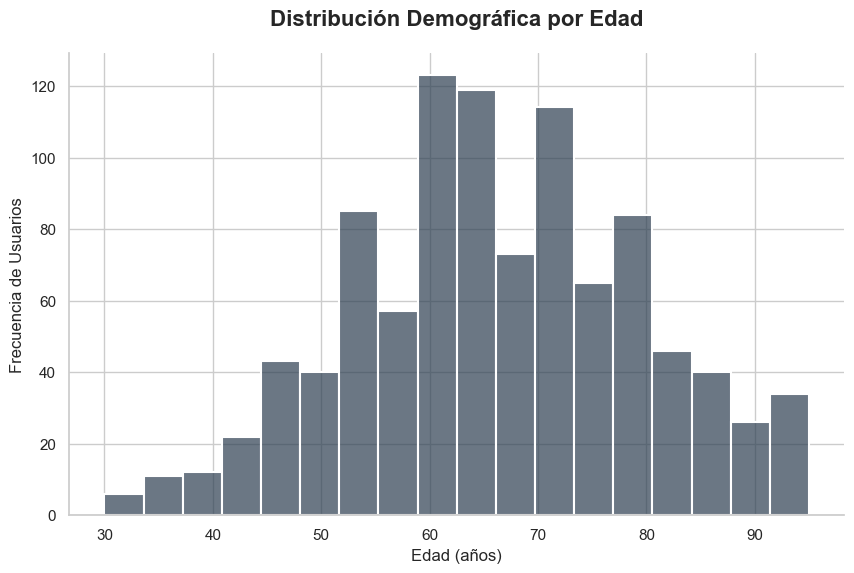

Media de edad: 66.22 años
Mediana de edad: 66.00 años


In [7]:
# Distribución de Edad
plt.figure(figsize=(10, 6))

ax = sns.histplot(
    database['Edad (años)'],
    color="#2c3e50",
    edgecolor="white",
    linewidth=1.5,
    alpha=0.7
)

plt.title('Distribución Demográfica por Edad', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Edad (años)', fontsize=12)
plt.ylabel('Frecuencia de Usuarios', fontsize=12)
sns.despine()

# Guardar figura
plots_dir = os.path.join(os.path.dirname(os.getcwd()), 'results', 'plots')
plt.savefig(os.path.join(plots_dir, '01_distribucion_edad.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"Media de edad: {database['Edad (años)'].mean():.2f} años")
print(f"Mediana de edad: {database['Edad (años)'].median():.2f} años")

**Interpretación:** Los resultados muestran una mayor concentración de pacientes entre los 55 y 75 años, observándose una moda aproximada de 60 años. La distribución presenta una forma aproximadamente normal, sin presencia de valores atípicos extremos.

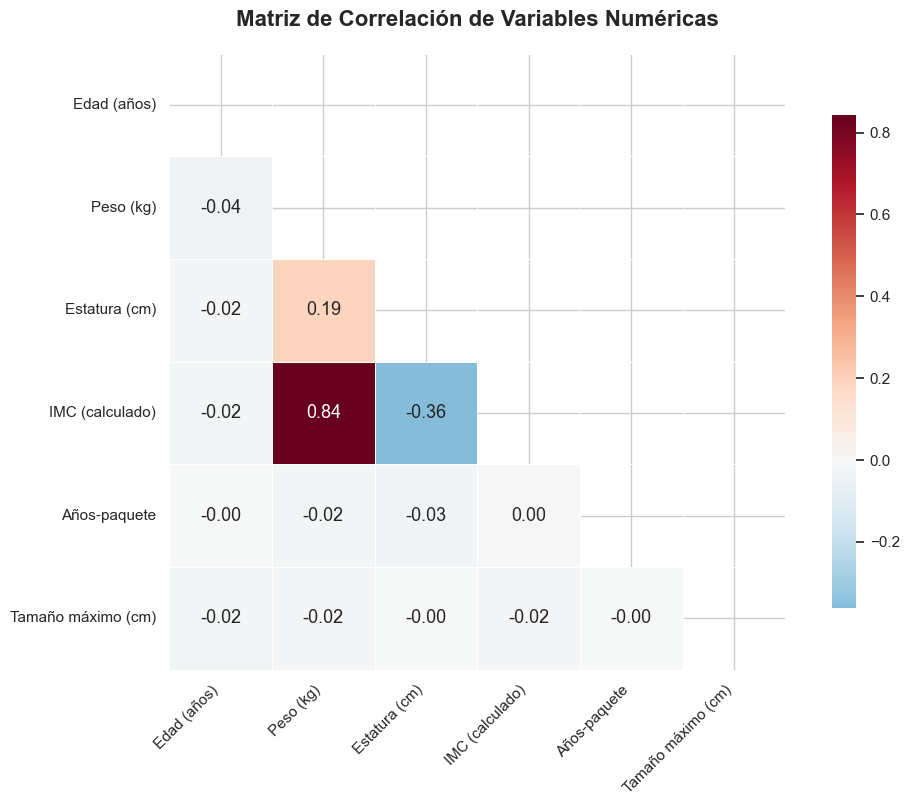

In [8]:
# Matriz de Correlación
corr = database.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap='RdBu_r',
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": .8},
    square=True
)
plt.title('Matriz de Correlación de Variables Numéricas', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.savefig(os.path.join(plots_dir, '02_matriz_correlacion.png'), dpi=300, bbox_inches='tight')
plt.show()

**Interpretación:** Se observa una correlación positiva fuerte entre el peso y el IMC (esperable por definición). El resto de las variables presentan correlaciones bajas, indicando que no existe redundancia significativa.

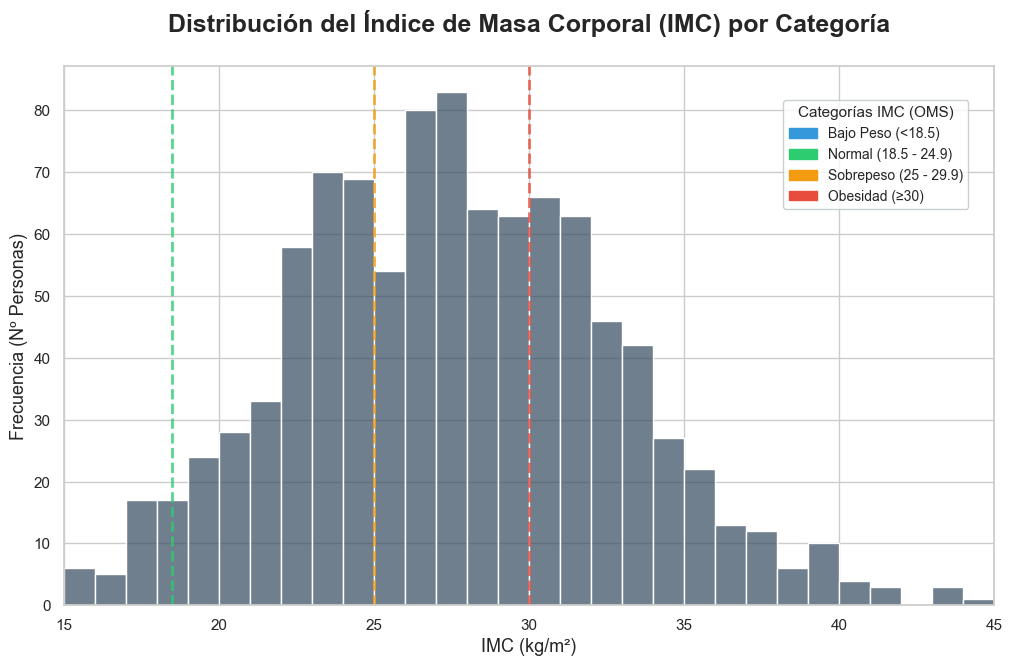

Media IMC: 27.50
Desv. Estándar IMC: 5.39


In [9]:
# Distribución del IMC
plt.figure(figsize=(12, 7))

bins = np.arange(15, 46, 1)
ax = sns.histplot(
    data=database,
    x='IMC (calculado)',
    bins=bins,
    color="#34495e",
    edgecolor="white",
    linewidth=1,
    alpha=0.7
)

# Líneas de categorías IMC
boundaries = [18.5, 25, 30]
line_colors = ['#2ecc71', '#f39c12', '#e74c3c']

for i, boundary in enumerate(boundaries):
    plt.axvline(x=boundary, color=line_colors[i], linestyle='--', linewidth=2, alpha=0.8)

legend_elements = [
    plt.matplotlib.patches.Patch(color='#3498db', label='Bajo Peso (<18.5)'),
    plt.matplotlib.patches.Patch(color='#2ecc71', label='Normal (18.5 - 24.9)'),
    plt.matplotlib.patches.Patch(color='#f39c12', label='Sobrepeso (25 - 29.9)'),
    plt.matplotlib.patches.Patch(color='#e74c3c', label='Obesidad (≥30)')
]

plt.legend(handles=legend_elements, title='Categorías IMC (OMS)', loc='upper right', 
          bbox_to_anchor=(0.98, 0.95), fontsize=10, title_fontsize=11, 
          frameon=True, fancybox=True, edgecolor='#bdc3c7')

plt.title('Distribución del Índice de Masa Corporal (IMC) por Categoría', fontsize=18, fontweight='bold', pad=25)
plt.xlabel('IMC (kg/m²)', fontsize=13)
plt.ylabel('Frecuencia (Nº Personas)', fontsize=13)
plt.xlim(15, 45)

plt.savefig(os.path.join(plots_dir, '03_distribucion_imc.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"Media IMC: {database['IMC (calculado)'].mean():.2f}")
print(f"Desv. Estándar IMC: {database['IMC (calculado)'].std():.2f}")

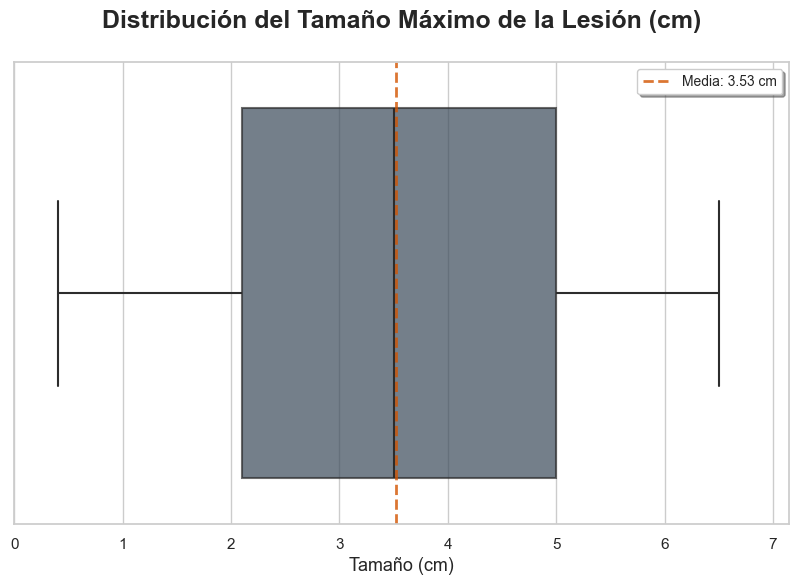

Mediana tamaño: 3.50 cm
Media tamaño: 3.53 cm


In [10]:
# Distribución del Tamaño de la Lesión
plt.figure(figsize=(10, 6))

boxplot = sns.boxplot(
    x=database['Tamaño máximo (cm)'],
    color="#34495e",
    linewidth=1.5,
    boxprops=dict(alpha=0.7),
    flierprops={'marker': 'o', 'markersize': 5, 'markerfacecolor': '#c0392b', 
                'markeredgecolor': 'white', 'markeredgewidth': 1.5, 'alpha': 0.9}
)

x_data = database['Tamaño máximo (cm)']
median_val = x_data.median()
mean_val = x_data.mean()

plt.axvline(x=mean_val, color='#d35400', linestyle='--', linewidth=2,
            label=f'Media: {mean_val:.2f} cm', alpha=0.8)

plt.title('Distribución del Tamaño Máximo de la Lesión (cm)', fontsize=18, fontweight='bold', pad=25)
plt.xlabel('Tamaño (cm)', fontsize=13)
plt.xlim(0, max(x_data) * 1.1)

plt.legend(loc='upper right', frameon=True, fancybox=True, shadow=True, fontsize=10)
plt.savefig(os.path.join(plots_dir, '04_boxplot_tamano_lesion.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"Mediana tamaño: {median_val:.2f} cm")
print(f"Media tamaño: {mean_val:.2f} cm")

## 3. Análisis de Variables Categóricas

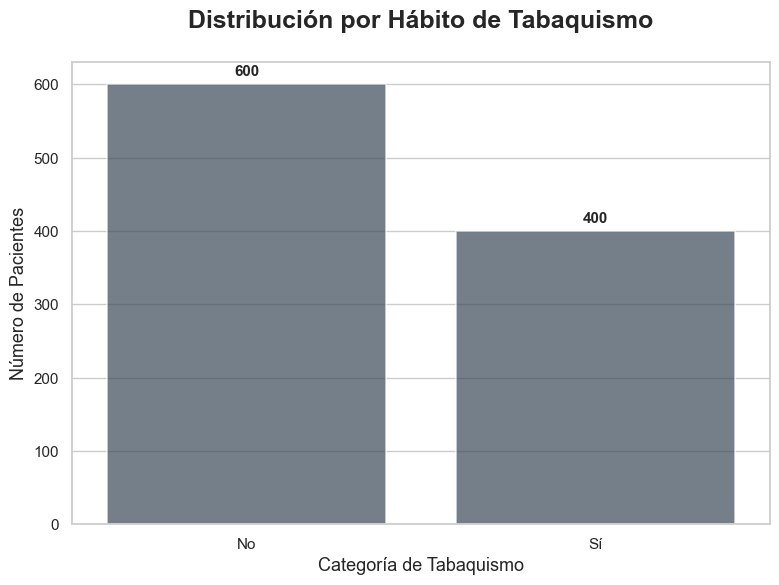

Tabaquismo
No    600
Sí    400
Name: count, dtype: int64


In [11]:
# Distribución por Tabaquismo
plt.figure(figsize=(9, 6))

order = database['Tabaquismo'].value_counts().index

ax = sns.countplot(
    x='Tabaquismo',
    data=database,
    order=order,
    edgecolor="white",
    linewidth=1.2,
    color="#34495e",
    alpha=0.7
)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=11,
                fontweight='bold')

plt.title('Distribución por Hábito de Tabaquismo', fontsize=18, fontweight='bold', pad=25)
plt.xlabel('Categoría de Tabaquismo', fontsize=13)
plt.ylabel('Número de Pacientes', fontsize=13)

plt.savefig(os.path.join(plots_dir, '05_tabaquismo.png'), dpi=300, bbox_inches='tight')
plt.show()

print(database['Tabaquismo'].value_counts())

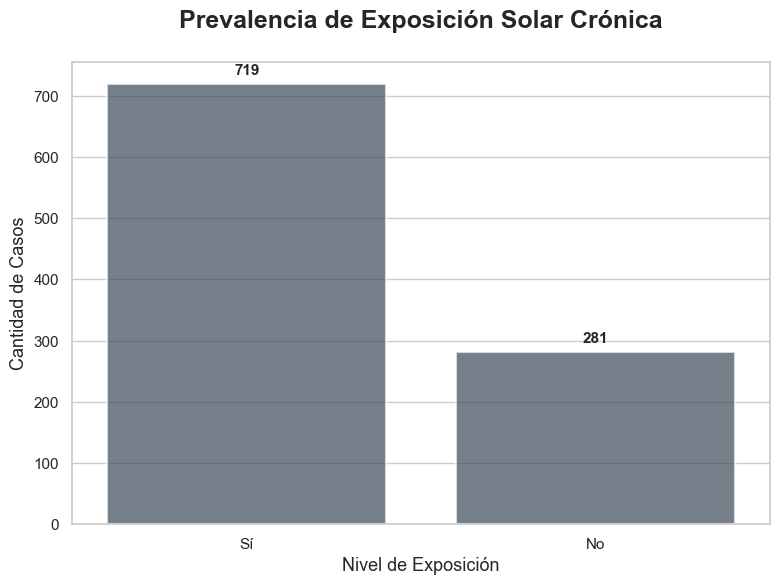

Exposición solar crónica
Sí    719
No    281
Name: count, dtype: int64


In [12]:
# Distribución por Exposición Solar Crónica
plt.figure(figsize=(9, 6))

order = database['Exposición solar crónica'].value_counts().index

ax = sns.countplot(
    x='Exposición solar crónica',
    data=database,
    order=order,
    edgecolor="white",
    color="#34495e",
    alpha=0.7,
    linewidth=1.5
)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='center',
                xytext=(0, 10),
                textcoords='offset points',
                fontsize=11,
                fontweight='bold')

plt.title('Prevalencia de Exposición Solar Crónica', fontsize=18, fontweight='bold', pad=25)
plt.xlabel('Nivel de Exposición', fontsize=13)
plt.ylabel('Cantidad de Casos', fontsize=13)

plt.savefig(os.path.join(plots_dir, '06_exposicion_solar.png'), dpi=300, bbox_inches='tight')
plt.show()

print(database['Exposición solar crónica'].value_counts())

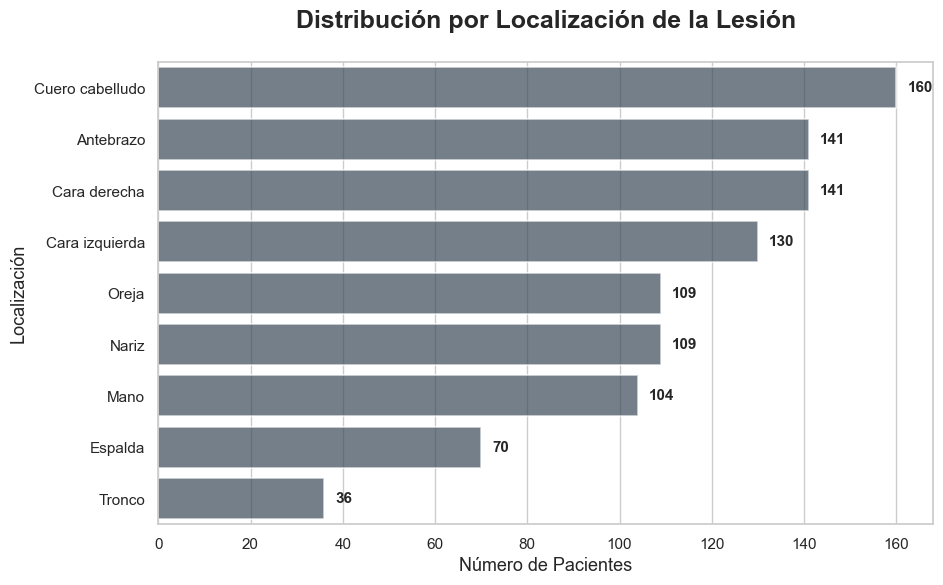

Localización de la lesión
Cuero cabelludo    160
Antebrazo          141
Cara derecha       141
Cara izquierda     130
Oreja              109
Nariz              109
Mano               104
Espalda             70
Tronco              36
Name: count, dtype: int64


In [13]:
# Distribución por Localización de la Lesión
plt.figure(figsize=(10, 6))

order = database['Localización de la lesión'].value_counts().index

ax = sns.countplot(
    y='Localización de la lesión',
    data=database,
    order=order,
    edgecolor="white",
    color="#34495e",
    alpha=0.7,
    linewidth=1.2
)

for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{int(width)}',
                (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                xytext=(8, 0),
                textcoords='offset points',
                fontsize=11,
                fontweight='bold')

plt.title('Distribución por Localización de la Lesión', fontsize=18, fontweight='bold', pad=25)
plt.xlabel('Número de Pacientes', fontsize=13)
plt.ylabel('Localización', fontsize=13)

plt.savefig(os.path.join(plots_dir, '07_localizacion_lesion.png'), dpi=300, bbox_inches='tight')
plt.show()

print(database['Localización de la lesión'].value_counts())

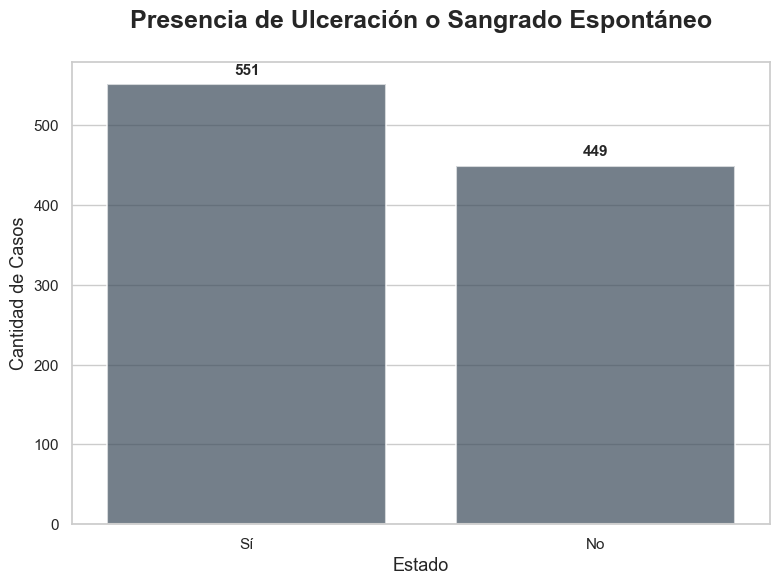

Ulceración o sangrado espontáneo
Sí    551
No    449
Name: count, dtype: int64


In [14]:
# Presencia de Ulceración o Sangrado Espontáneo
plt.figure(figsize=(9, 6))

order = database['Ulceración o sangrado espontáneo'].value_counts().index

ax = sns.countplot(
    x='Ulceración o sangrado espontáneo',
    data=database,
    order=order,
    edgecolor="white",
    color="#34495e",
    alpha=0.7,
    linewidth=1.5
)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='center',
                xytext=(0, 10),
                textcoords='offset points',
                fontsize=11,
                fontweight='bold')

plt.title('Presencia de Ulceración o Sangrado Espontáneo', fontsize=18, fontweight='bold', pad=25)
plt.xlabel('Estado', fontsize=13)
plt.ylabel('Cantidad de Casos', fontsize=13)

plt.savefig(os.path.join(plots_dir, '08_ulceracion_sangrado.png'), dpi=300, bbox_inches='tight')
plt.show()

print(database['Ulceración o sangrado espontáneo'].value_counts())

## 4. Feature Engineering - Creación del Target

In [15]:
# Crear copia de trabajo
df_trabajo = database.copy()

# Verificar columnas disponibles
print("Columnas disponibles:")
print(df_trabajo.columns.tolist())

Columnas disponibles:
['Edad (años)', 'Sexo', 'Peso (kg)', 'Estatura (cm)', 'IMC (calculado)', 'Tabaquismo', 'Años-paquete', 'Consumo de alcohol', 'Inmunosupresión', 'Exposición solar crónica', 'Antecedentes personales de cáncer', 'Cáncer familiar 1er grado (tipo)', 'Localización de la lesión', 'Tiempo de evolución', 'Tamaño máximo (cm)', 'Dolor', 'Ulceración o sangrado espontáneo', 'Costra persistente', 'Bordes elevados/irregulares', 'Endurecimiento', 'Supuración', 'Cambio reciente de tamaño/color', 'Sutura o manipulación previa', 'Respuesta a antibióticos previos', 'Pérdida de peso involuntaria', 'Fiebre persistente', 'Fatiga']


In [16]:
# Crear target usando función del módulo
df_trabajo = create_target_variable(df_trabajo)

# Estadísticas del target
print("\n📊 Estadísticas del Target creado:")
print(df_trabajo['diagnostico'].value_counts())
print("-" * 40)

Target creado. Distribución:
diagnostico
1    990
0     10
Name: count, dtype: int64
Porcentaje clase 1: 99.00%

📊 Estadísticas del Target creado:
diagnostico
1    990
0     10
Name: count, dtype: int64
----------------------------------------


In [17]:
# Análisis del desbalance
porcentaje_alto_riesgo = (df_trabajo['diagnostico'].sum() / len(df_trabajo)) * 100
print(f"Porcentaje de pacientes con signos de alarma: {porcentaje_alto_riesgo:.2f}%")

Porcentaje de pacientes con signos de alarma: 99.00%


**⚠️ Nota importante:** El target está extremadamente desbalanceado (99% vs 1%). Esto será considerado en los notebooks de modelado.

## 5. Análisis Bivariado - Relación con el Target

C:\Users\dpere\AppData\Local\Temp\ipykernel_37496\315073832.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


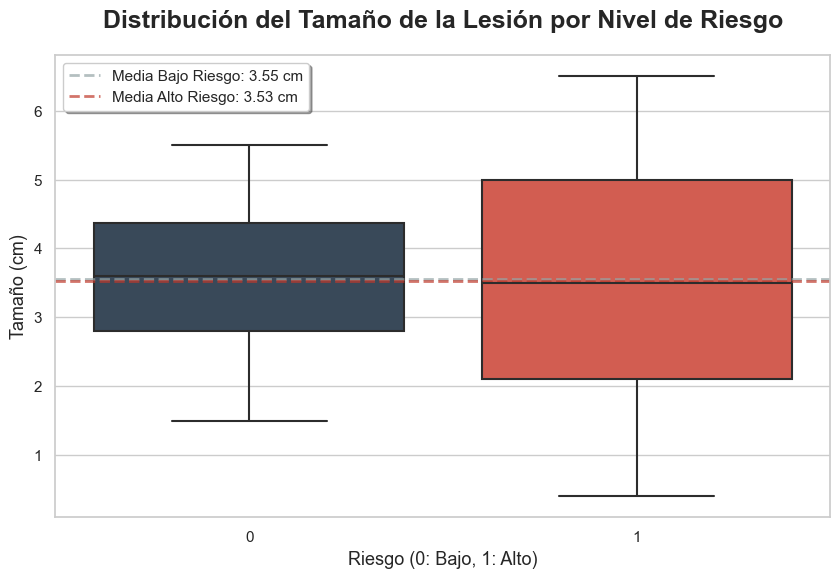

In [18]:
# Tamaño máximo vs Diagnóstico
plt.figure(figsize=(10, 6))

sns.boxplot(
    x='diagnostico',
    y='Tamaño máximo (cm)',
    data=df_trabajo,
    palette=['#34495e', '#e74c3c'],
    linewidth=1.5,
    flierprops={'marker': 'o', 'markersize': 4, 'markerfacecolor': '#e74c3c', 
                'markeredgecolor': 'white'}
)

media_0 = df_trabajo[df_trabajo['diagnostico'] == 0]['Tamaño máximo (cm)'].mean()
media_1 = df_trabajo[df_trabajo['diagnostico'] == 1]['Tamaño máximo (cm)'].mean()

plt.axhline(y=media_0, color='#95a5a6', linestyle='--', linewidth=2, alpha=0.7, 
            label=f'Media Bajo Riesgo: {media_0:.2f} cm')
plt.axhline(y=media_1, color='#c0392b', linestyle='--', linewidth=2, alpha=0.7, 
            label=f'Media Alto Riesgo: {media_1:.2f} cm')

plt.title('Distribución del Tamaño de la Lesión por Nivel de Riesgo', fontsize=18, pad=20)
plt.xlabel('Riesgo (0: Bajo, 1: Alto)', fontsize=13)
plt.ylabel('Tamaño (cm)', fontsize=13)
plt.legend(frameon=True, fancybox=True, shadow=True, fontsize=11)

plt.savefig(os.path.join(plots_dir, '09_tamano_vs_diagnostico.png'), dpi=300, bbox_inches='tight')
plt.show()

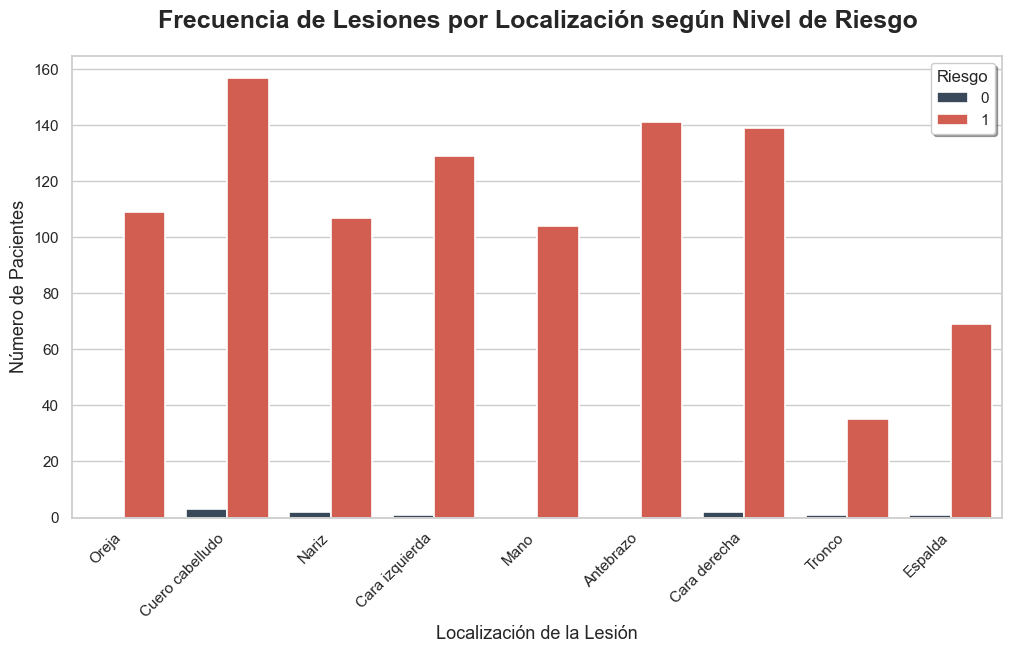

In [19]:
# Localización vs Diagnóstico
plt.figure(figsize=(12, 6))

sns.countplot(
    data=df_trabajo,
    x='Localización de la lesión',
    hue='diagnostico',
    palette=['#34495e', '#e74c3c'],
    edgecolor='white',
    linewidth=1.2
)

plt.title('Frecuencia de Lesiones por Localización según Nivel de Riesgo', fontsize=18, pad=20)
plt.xlabel('Localización de la Lesión', fontsize=13)
plt.ylabel('Número de Pacientes', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Riesgo', title_fontsize=12, fontsize=11, frameon=True, fancybox=True, shadow=True)

plt.savefig(os.path.join(plots_dir, '10_localizacion_vs_diagnostico.png'), dpi=300, bbox_inches='tight')
plt.show()

C:\Users\dpere\AppData\Local\Temp\ipykernel_37496\3441866791.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


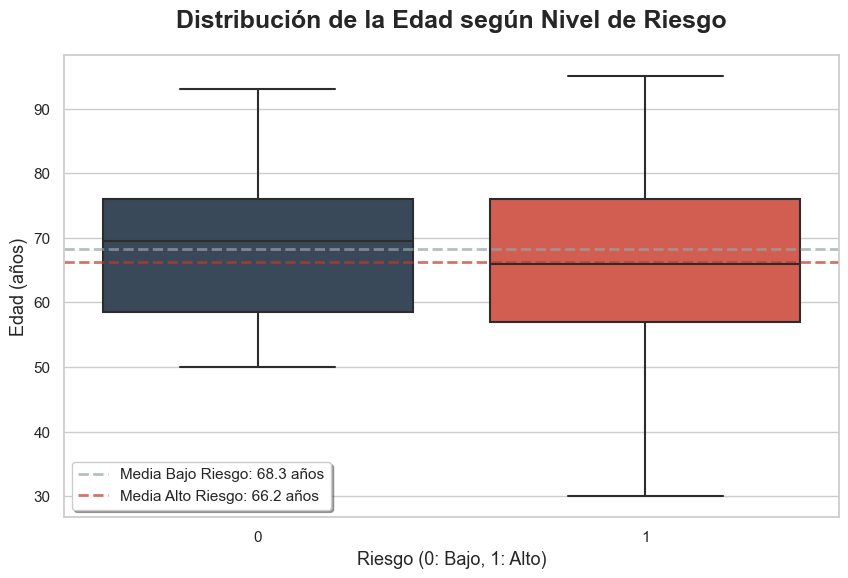

In [20]:
# Edad vs Diagnóstico
plt.figure(figsize=(10, 6))

sns.boxplot(
    x='diagnostico',
    y='Edad (años)',
    data=df_trabajo,
    palette=['#34495e', '#e74c3c'],
    linewidth=1.5,
    flierprops={'marker': 'o', 'markersize': 4, 'markerfacecolor': '#e74c3c', 
                'markeredgecolor': 'white'}
)

media_edad_0 = df_trabajo[df_trabajo['diagnostico'] == 0]['Edad (años)'].mean()
media_edad_1 = df_trabajo[df_trabajo['diagnostico'] == 1]['Edad (años)'].mean()

plt.axhline(y=media_edad_0, color='#95a5a6', linestyle='--', linewidth=2, alpha=0.7, 
            label=f'Media Bajo Riesgo: {media_edad_0:.1f} años')
plt.axhline(y=media_edad_1, color='#c0392b', linestyle='--', linewidth=2, alpha=0.7, 
            label=f'Media Alto Riesgo: {media_edad_1:.1f} años')

plt.title('Distribución de la Edad según Nivel de Riesgo', fontsize=18, pad=20)
plt.xlabel('Riesgo (0: Bajo, 1: Alto)', fontsize=13)
plt.ylabel('Edad (años)', fontsize=13)
plt.legend(frameon=True, fancybox=True, shadow=True, fontsize=11)

plt.savefig(os.path.join(plots_dir, '11_edad_vs_diagnostico.png'), dpi=300, bbox_inches='tight')
plt.show()

## 6. Guardar Dataset Procesado

In [21]:
# Guardar dataset con el target creado
processed_path = os.path.join(os.path.dirname(os.getcwd()), 'data', 'processed', 'df_processed.csv')
df_trabajo.to_csv(processed_path, index=False)
print(f"Dataset procesado guardado en: {processed_path}")
print(f"Dimensiones finales: {df_trabajo.shape}")

Dataset procesado guardado en: c:\Users\dpere\OneDrive\Desktop\pplcdd\data\processed\df_processed.csv
Dimensiones finales: (1000, 28)


## Resumen del Análisis Exploratorio

### Hallazgos principales:

1. **Demografía**: Población predominantemente adulta mayor (55-75 años, media ~60)
2. **IMC**: Distribución normal con presencia de sobrepeso y obesidad
3. **Factores de riesgo**: Alta prevalencia de exposición solar crónica
4. **Localización**: Concentración en cabeza/cuello y extremidades superiores
5. **Target desbalanceado**: 99% de pacientes tienen al menos un signo de alarma

### Próximo paso:
Continuar con `02_supervised_modeling.ipynb` para implementar modelos de clasificación.